<a href="https://colab.research.google.com/github/lseidy/IA_learning/blob/main/CNN_MINIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercício — CNN no MNIST

No notebook anterior, construímos uma CNN para classificar imagens do **CIFAR-10** (objetos coloridos 32×32).

Agora é a sua vez! O objetivo é **adaptar a CNN para classificar os dígitos do MNIST** (0 a 9).

Os dados já estão carregados abaixo. Sua tarefa é:
1. Definir a arquitetura da CNN (usando `nn.Module`)
2. Treinar o modelo
3. Avaliar e visualizar os resultados

Use como base o código do notebook da CNN com CIFAR-10!

**Dicas importantes:**
- O MNIST tem imagens **1×28×28** (1 canal, preto e branco), não 3×32×32 como o CIFAR-10
- A primeira convolução muda: `nn.Conv2d(1, ...)` em vez de `nn.Conv2d(3, ...)`
- O tamanho da camada Linear após as convoluções será diferente (a imagem é 28×28, não 32×32)

## 1. Setup e imports

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
np.random.seed(42)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"PyTorch versão: {torch.__version__}")
print(f"Device: {device}")

PyTorch versão: 2.10.0+cpu
Device: cpu


## 2. Carregando o MNIST

In [ ]:
CLASSES = [str(i) for i in range(10)]  # ['0', '1', ..., '9']

transform = transforms.Compose([transforms.ToTensor()])

train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.MNIST(
    root='./data', train=False, download=True, transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

print(f"Treino: {len(train_dataset)} amostras")
print(f"Teste:  {len(test_dataset)} amostras")
print(f"Classes: 10 dígitos (0 a 9)")
print(f"Tamanho da imagem: 1 × 28 × 28")
print(f"\nDataLoaders criados!")
print(f"  Treino: {len(train_loader)} batches de 64")
print(f"  Teste:  {len(test_loader)} batches de 1000")

100%|██████████| 9.91M/9.91M [00:00<00:00, 121MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 30.3MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 80.7MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.56MB/s]


Treino: 60000 amostras
Teste:  10000 amostras
Classes: 10 dígitos (0 a 9)
Tamanho da imagem: 1 × 28 × 28

DataLoaders criados!
  Treino: 938 batches de 64
  Teste:  10 batches de 1000


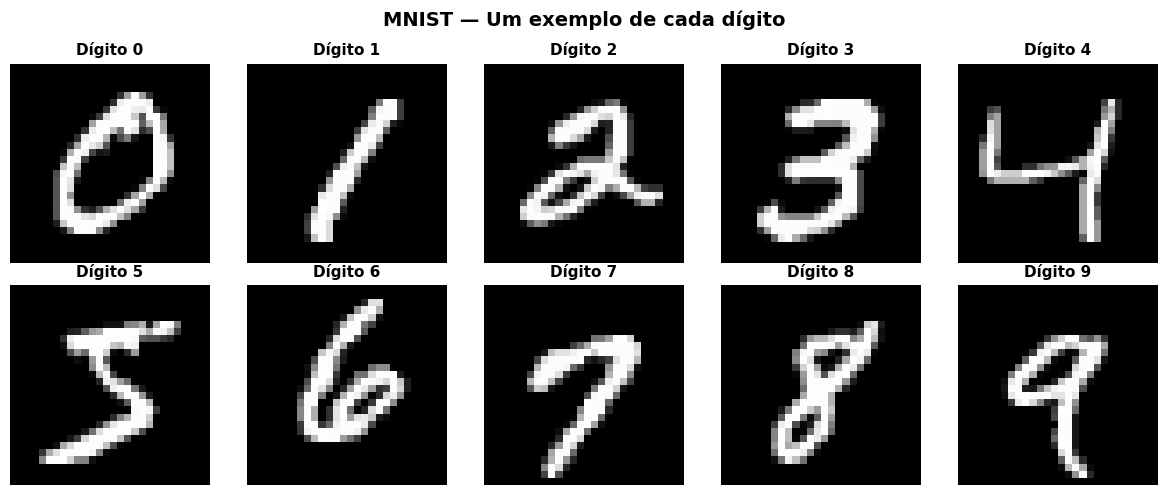

In [ ]:
# Visualizando 1 exemplo de cada dígito
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

for digito in range(10):
    for i in range(len(train_dataset)):
        if train_dataset.targets[i] == digito:
            img, _ = train_dataset[i]
            axes[digito].imshow(img.squeeze(), cmap='gray')
            axes[digito].set_title(f'Dígito {digito}', fontsize=11, fontweight='bold')
            axes[digito].axis('off')
            break

plt.suptitle('MNIST — Um exemplo de cada dígito', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Agora é com você!

Os dados estão prontos. Usando como referência o notebook da **CNN com CIFAR-10**, implemente:

1. **Defina a arquitetura da CNN** — lembre das diferenças abaixo
2. **Defina a loss e o otimizador** — `CrossEntropyLoss` + `SGD`
3. **Treine o modelo** — copie/adapte as funções `treinar()` e `avaliar()`
4. **Visualize os resultados** — curvas de treinamento, matriz de confusão, predições

### O que muda do CIFAR-10 para o MNIST?

| | CIFAR-10 (antes) | MNIST (agora) |
|---|---|---|
| **Canais de entrada** | 3 (RGB) | 1 (preto e branco) |
| **Tamanho da imagem** | 32×32 | 28×28 |
| **Primeira Conv2d** | `nn.Conv2d(3, 32, ...)` | `nn.Conv2d(1, 32, ...)` |
| **Camada Linear** | Tamanho diferente após as convoluções | Precisa recalcular! |

**Dica para calcular o tamanho da Linear:** depois de aplicar as convoluções e poolings, faça um teste passando um tensor de exemplo para descobrir o tamanho:

```python
# Teste rápido para descobrir o tamanho após as convoluções:
teste = torch.randn(1, 1, 28, 28)  # 1 imagem, 1 canal, 28×28
# passe por todas as camadas convolucionais e veja o shape da saída
```

O resto da arquitetura (Conv2d, MaxPool2d, ReLU, camadas finais com 10 classes) funciona igual!

## 4. Arquitetura da CNN

In [ ]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()

        self.fc1 = nn.Linear(128 * 3 * 3, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x


In [ ]:
# Teste rápido: tamanho após convoluções/poolings
with torch.no_grad():
    teste = torch.randn(1, 1, 28, 28).to(device)
    modelo_teste = CNN().to(device)
    x = modelo_teste.pool(modelo_teste.relu(modelo_teste.conv1(teste)))
    x = modelo_teste.pool(modelo_teste.relu(modelo_teste.conv2(x)))
    x = modelo_teste.pool(modelo_teste.relu(modelo_teste.conv3(x)))
    print(f"Shape após convoluções/poolings: {x.shape} → {x.numel() // x.size(0)} features por imagem")



Shape após convoluções/poolings: torch.Size([1, 128, 3, 3]) → 1152 features por imagem


## Treino

In [ ]:
def avaliar(modelo, loader):
    modelo.eval()
    acertos = 0
    total = 0
    with torch.no_grad():
        for imagens, labels in loader:
            imagens, labels = imagens.to(device), labels.to(device)
            saidas = modelo(imagens)
            _, preditos = saidas.max(1)
            acertos += (preditos == labels).sum().item()
            total += labels.size(0)
    return acertos / total

def treinar(modelo, train_loader, test_loader, optimizer, epochs=10):
    criterion = nn.CrossEntropyLoss()
    historico = {"loss": [], "acc_treino": [], "acc_teste": []}

    for epoch in range(epochs):
        modelo.train()
        loss_total = 0.0
        acertos = 0
        total = 0

        for imagens, labels in train_loader:
            imagens, labels = imagens.to(device), labels.to(device)

            saidas = modelo(imagens)
            loss = criterion(saidas, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            loss_total += loss.item()
            _, preditos = saidas.max(1)
            acertos += (preditos == labels).sum().item()
            total += labels.size(0)

        acc_treino = acertos / total
        acc_teste = avaliar(modelo, test_loader)
        loss_media = loss_total / len(train_loader)

        historico["loss"].append(loss_media)
        historico["acc_treino"].append(acc_treino)
        historico["acc_teste"].append(acc_teste)

        print(
            f"Época {epoch + 1:2d}/{epochs} | "
            f"Loss: {loss_media:.4f} | "
            f"Acc treino: {acc_treino:.4f} | "
            f"Acc teste: {acc_teste:.4f}"
        )

    return historico

In [ ]:
print("\n" + "═" * 60)
print("  TREINAMENTO DA CNN (MNIST – 1×28×28) ")
print("═" * 60)

cnn = CNN().to(device)
opt_cnn = optim.SGD(cnn.parameters(), lr=0.01, momentum=0.9)
hist_cnn = treinar(cnn, train_loader, test_loader, opt_cnn, epochs=10)



════════════════════════════════════════════════════════════
  TREINAMENTO DA CNN (MNIST – 1×28×28) 
════════════════════════════════════════════════════════════
Época  1/10 | Loss: 0.4009 | Acc treino: 0.8734 | Acc teste: 0.9743
Época  2/10 | Loss: 0.0672 | Acc treino: 0.9794 | Acc teste: 0.9848
Época  3/10 | Loss: 0.0458 | Acc treino: 0.9855 | Acc teste: 0.9897
Época  4/10 | Loss: 0.0344 | Acc treino: 0.9892 | Acc teste: 0.9913
Época  5/10 | Loss: 0.0271 | Acc treino: 0.9915 | Acc teste: 0.9891
Época  6/10 | Loss: 0.0216 | Acc treino: 0.9932 | Acc teste: 0.9925
Época  7/10 | Loss: 0.0183 | Acc treino: 0.9947 | Acc teste: 0.9914
Época  8/10 | Loss: 0.0155 | Acc treino: 0.9953 | Acc teste: 0.9915
Época  9/10 | Loss: 0.0139 | Acc treino: 0.9957 | Acc teste: 0.9915
Época 10/10 | Loss: 0.0094 | Acc treino: 0.9971 | Acc teste: 0.9914


## Curvas de Treinamento

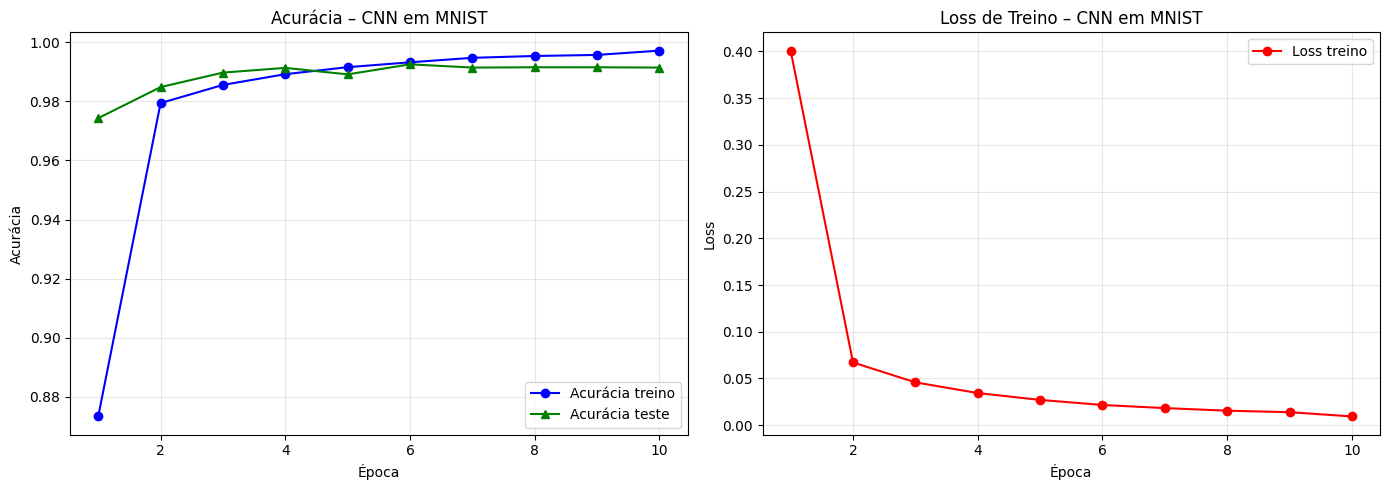

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epocas = range(1, len(hist_cnn["loss"]) + 1)

axes[0].plot(epocas, hist_cnn["acc_treino"], "b-o", label="Acurácia treino")
axes[0].plot(epocas, hist_cnn["acc_teste"], "g-^", label="Acurácia teste")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Acurácia")
axes[0].set_title("Acurácia – CNN em MNIST")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epocas, hist_cnn["loss"], "r-o", label="Loss treino")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Loss")
axes[1].set_title("Loss de Treino – CNN em MNIST")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Matriz de Confusão

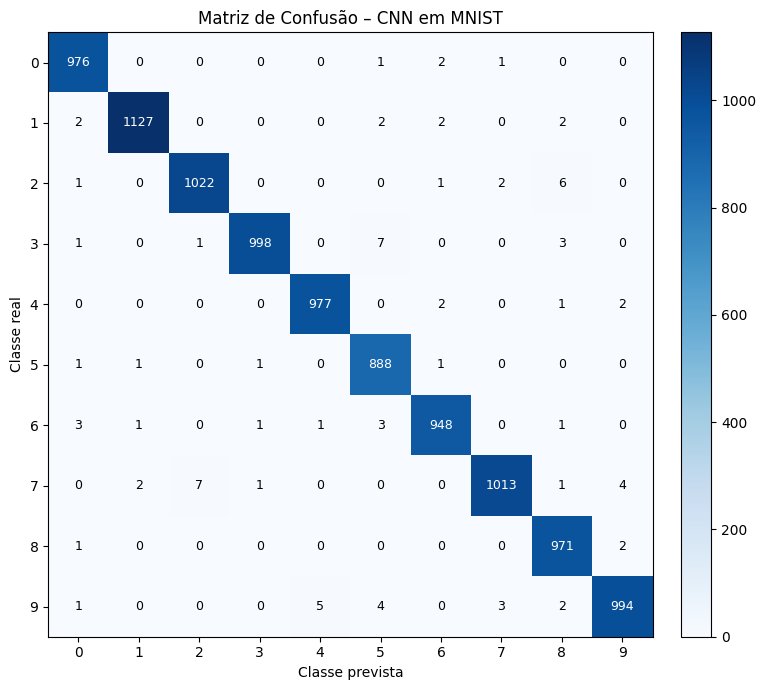

Acurácia por classe (CNN em MNIST):
  Dígito 0: 99.59%
  Dígito 1: 99.30%
  Dígito 2: 99.03%
  Dígito 3: 98.81%
  Dígito 4: 99.49%
  Dígito 5: 99.55%
  Dígito 6: 98.96%
  Dígito 7: 98.54%
  Dígito 8: 99.69%
  Dígito 9: 98.51%


In [ ]:
cnn.eval()
todas_preds = []
todos_labels = []

with torch.no_grad():
    for imagens, labels in test_loader:
        imagens = imagens.to(device)
        saidas = cnn(imagens)
        _, preditos = saidas.max(1)
        todas_preds.extend(preditos.cpu().numpy())
        todos_labels.extend(labels.numpy())

matriz = np.zeros((10, 10), dtype=int)
for real, pred in zip(todos_labels, todas_preds):
    matriz[real][pred] += 1

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(matriz, cmap="Blues")

for i in range(10):
    for j in range(10):
        cor = "white" if matriz[i, j] > matriz.max() * 0.5 else "black"
        ax.text(j, i, str(matriz[i, j]), ha="center", va="center", color=cor, fontsize=9)

ax.set_xticks(range(10))
ax.set_yticks(range(10))
ax.set_xticklabels(CLASSES)
ax.set_yticklabels(CLASSES)
ax.set_xlabel("Classe prevista")
ax.set_ylabel("Classe real")
ax.set_title("Matriz de Confusão – CNN em MNIST")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

print("Acurácia por classe (CNN em MNIST):")
for i in range(10):
    acc_classe = matriz[i, i] / matriz[i].sum()
    print(f"  Dígito {i}: {acc_classe:.2%}")

## Visualização

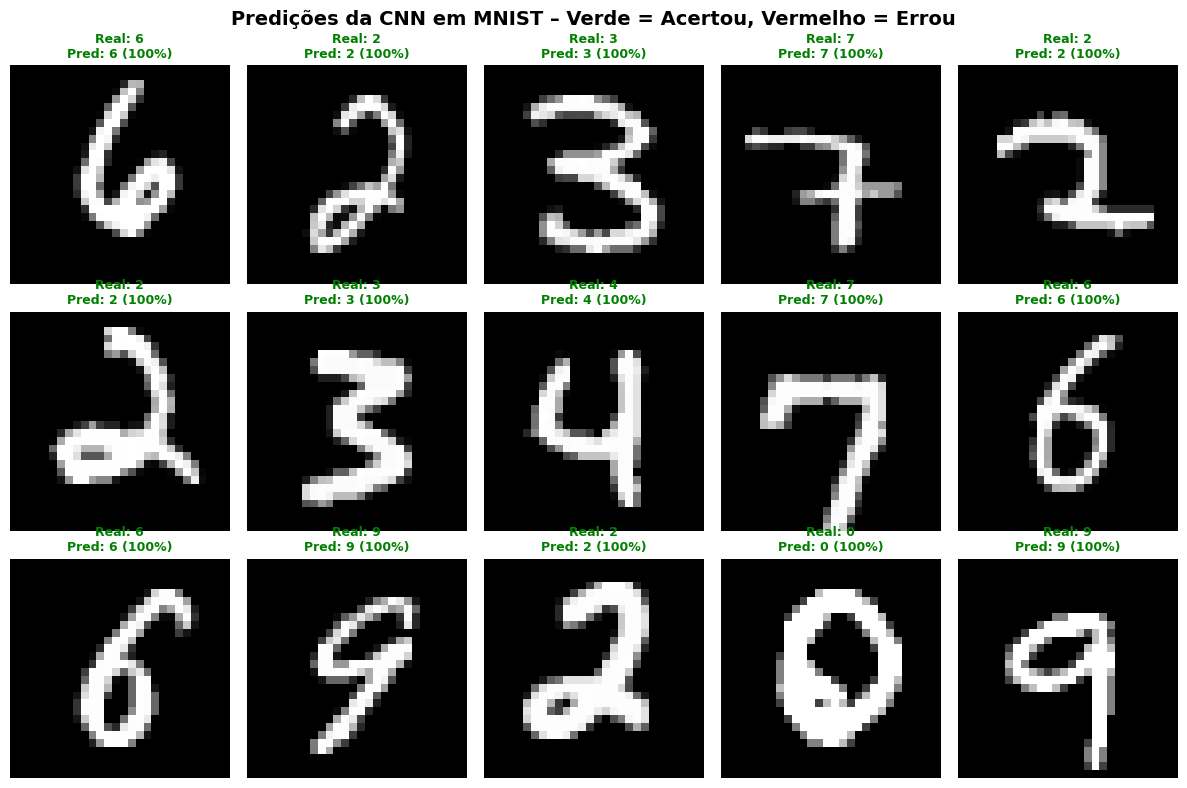

In [ ]:
n_exemplos = 15
indices = np.random.choice(len(test_dataset), n_exemplos, replace=False)

fig, axes = plt.subplots(3, 5, figsize=(12, 8))
axes = axes.flatten()

cnn.eval()
with torch.no_grad():
    for i, idx in enumerate(indices):
        img, label_real = test_dataset[idx]
        img_device = img.unsqueeze(0).to(device)

        saida = cnn(img_device)
        probs = torch.softmax(saida, dim=1)
        confianca, pred = probs.max(1)
        pred = pred.item()
        confianca = confianca.item()

        acertou = pred == label_real
        cor = "green" if acertou else "red"

        axes[i].imshow(img.squeeze().numpy(), cmap="gray")
        axes[i].set_title(
            f"Real: {label_real}\nPred: {pred} ({confianca:.0%})",
            fontsize=9,
            color=cor,
            fontweight="bold",
        )
        axes[i].axis("off")

plt.suptitle("Predições da CNN em MNIST – Verde = Acertou, Vermelho = Errou",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()